# Biomechanical parameters — video vs. Optojump

Computes ground contact time, flight time, and step length from pose-based gait phase
predictions, then compares them to Optojump ground-truth measurements.

**Optojump filter:** only steps after the 20 m mark (`distance > 2000 cm`) are used
to avoid acceleration-phase artefacts.

**Predictions source:** TCN inference manifest (`stage6`).  Falls back to ground-truth
labels from the annotation CSV if the manifest is absent.

In [ ]:
import json
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy import ndarray

from experiments.gait_detection.config import ExperimentConfig
from src.gait.detection.detectors import KinematicDetector, XGBoostDetector
from src.gait.detection.postprocess import smooth_probs_argmax
from src.gait.gait_data.dataset import load_dataset_with_pose, VideoRecord
from src.gait.parameters.biomechanics import (
    gait_intervals,
    compute_cadence,
    compute_step_lengths,
    compute_joint_angles,
)

In [ ]:
# Label source: "tcn" | "xgb" | "kinematic" | "annotations"
LABEL_SOURCE = "tcn"

# paths
TCN_MANIFEST   = "data/output/gait/pose_data/stage6/manifest.json"
XGB_MODEL_PATH = "data/output/gait/pose_data/stage3/checkpoints/model.pkl"
XGB_FEATURE_IDX = list(range(20))  # features 0–19 (as trained in stage3)

OPTOJUMP_CSV    = "data/input/optojump/optojump_output/parsed/optojump_basic.csv"
RUNNER_HEIGHT_M = 2.0
POSTPROCESS_WIN = 3    # window for TCN soft-label smoothing
MIN_DISTANCE_CM = 2000

In [3]:
os.chdir('..')

## Load pose data + predictions

In [4]:
_manifest_idx: dict | None = None

def load_tcn_manifest():
    manifest_idx: dict = {}
    try:
        with open(TCN_MANIFEST) as f:
            manifest = json.load(f)
        manifest_idx = {r["video_path"]: r for r in manifest["records"]}
        print(f"Manifest loaded — {len(manifest_idx)} records, trial #{manifest['trial_id']}")
    except FileNotFoundError:
        if LABEL_SOURCE == "tcn":
            raise FileNotFoundError(f"TCN manifest not found: {TCN_MANIFEST}")
    return manifest_idx

In [5]:
cfg = ExperimentConfig()
cfg.annotations_csv = "data/output/annotations/optojump/ml_training_dataset_clean.csv"

pairs = load_dataset_with_pose(cfg.annotations_csv, fps=cfg.fps)

## Compute per-video biomechanical parameters

In [6]:
def load_labels_tcn(rec: VideoRecord) -> ndarray:
    global _manifest_idx
    if _manifest_idx is None:
        _manifest_idx = load_tcn_manifest()
    entry = _manifest_idx[rec.video_path]
    probs = np.load(entry["probs_path"])
    return smooth_probs_argmax(probs, window=POSTPROCESS_WIN)


#_xgb_detector: XGBoostDetector | None = None

def load_labels_xgb(rec: VideoRecord) -> ndarray:
    # global _xgb_detector
    # if _xgb_detector is None:
    _xgb_detector = XGBoostDetector(XGB_MODEL_PATH, XGB_FEATURE_IDX)
    return _xgb_detector.predict(rec.features, cfg.fps)


def load_labels_kinematic(rec: VideoRecord) -> ndarray:
    return KinematicDetector().predict(rec.features, cfg.fps)


def load_labels_annotations(rec: VideoRecord) -> ndarray:
    return rec.labels

In [7]:
def _study_test(video_path: str) -> tuple[int, int]:
    path = Path(video_path)
    study_match = re.search(r"study_(\d+)", video_path)
    study_id = int(study_match.group(1)) if study_match else 0
    try:
        test_id = int(path.stem.split("_")[-1])
    except (ValueError, IndexError):
        test_id = 0
    return study_id, test_id

In [ ]:
def make_bio_df(load_labels: callable) -> tuple[pd.DataFrame, dict]:
    results = []
    all_steps = {"contact": [], "flight": [], "length": []}

    for rec, pose_df in pairs:
        labels = load_labels(rec)

        study_id, test_id = _study_test(rec.video_path)
        meta = {"athlete": rec.athlete, "study_id": study_id, "test_id": test_id}

        ivs = gait_intervals(labels, fps=cfg.fps)
        cad = compute_cadence(labels, fps=cfg.fps)
        sl_df = compute_step_lengths(labels, pose_df, fps=cfg.fps, runner_height_m=RUNNER_HEIGHT_M)

        for key, source, col in [
            ("contact", ivs["contact"], "duration_s"),
            ("flight", ivs["flight"], "duration_s"),
        ]:
            step_df = pd.DataFrame(source).rename(columns={col: f"{key}_s"})
            all_steps[key].append(step_df.assign(**meta))

        all_steps["length"].append(sl_df[["step_length_m"]].dropna().assign(**meta))

        gcts = [c["duration_s"] for c in ivs["contact"]]
        flts = [f["duration_s"] for f in ivs["flight"]]
        sls  = sl_df["step_length_m"].dropna()

        results.append({
            **meta,
            "video_path": rec.video_path,
            "mean_gct_s": np.nanmean(gcts) if gcts else np.nan,
            "mean_flight_s": np.nanmean(flts) if flts else np.nan,
            "mean_step_length_m": np.nanmean(sls) if not sls.empty else np.nan,
            "cadence_spm": cad["steps_per_minute"],
            "n_steps": cad["n_steps"],
        })
    return pd.DataFrame(results), all_steps

In [10]:
_loaders = {
    "tcn":         lambda rec: load_labels_tcn(rec),
    "xgb":         load_labels_xgb,
    "kinematic":   load_labels_kinematic,
    "annotations": load_labels_annotations,
}
if LABEL_SOURCE not in _loaders:
    raise ValueError(f"Unknown LABEL_SOURCE={LABEL_SOURCE!r}. Choose from: {list(_loaders)}")

print(f"Computing biomechanics — label source: {LABEL_SOURCE!r}")
bio_df, all_steps = make_bio_df(_loaders[LABEL_SOURCE])
contact_all  = pd.concat(all_steps["contact"], ignore_index=True)
flight_all   = pd.concat(all_steps["flight"],  ignore_index=True)
step_len_all = pd.concat(all_steps["length"],  ignore_index=True)

Computing biomechanics — label source: 'tcn'
Manifest loaded — 178 records, trial #61


## Load and filter Optojump data

In [11]:
oj = pd.read_csv(OPTOJUMP_CSV)

# Keep only steps after the 20 m mark
oj_post20 = oj[oj["distance"] > MIN_DISTANCE_CM].copy()

# "Marcin Jung" → "marcin_jung"
oj_post20["athlete"] = (
    oj_post20["full_name"].str.lower().str.replace(" ", "_", regex=False)
)

# step_length in optojump is "steps" column (cm per individual step)
oj_post20["step_length_m_oj"] = oj_post20["steps"] / 100.0

oj_agg = oj_post20.groupby(["athlete", "study_id", "test_id"], as_index=False).agg(
    mean_gct_s_oj=("contact_time", "mean"),
    std_gct_s_oj=("contact_time", "std"),
    mean_flight_s_oj=("flight_time", "mean"),
    std_flight_s_oj=("flight_time", "std"),
    mean_step_len_m_oj=("step_length_m_oj", "mean"),
    std_step_len_m_oj=("step_length_m_oj", "std"),
    n_steps_oj=("contact_time", "count"),
)


## Merge video predictions with Optojump

In [12]:
merged = bio_df.merge(
    oj_agg,
    on=["athlete", "study_id", "test_id"],
    how="inner",
)  # video predictions + optojump

In [14]:
# Assign train/test split from manifest and report counts
merged["split"] = merged["video_path"].map(
    lambda vp: _manifest_idx[vp]["split"] if vp in _manifest_idx else "unknown"
)
n_train = (merged["split"] == "train").sum()
n_test  = (merged["split"] == "test").sum()
print(f"Matched: {len(merged)} total  —  train: {n_train},  test: {n_test}")

Matched: 117 total  —  train: 106,  test: 11


# Error analysis


In [15]:
METRICS = [
    ("mean_gct_s",         "mean_gct_s_oj",      "GCT (s)",          "#4e79a7"),
    ("mean_flight_s",      "mean_flight_s_oj",   "Flight time (s)",  "#59a14f"),
    ("mean_step_length_m", "mean_step_len_m_oj", "Step length (m)",  "#f28e2b"),
]
SPLITS = ["train", "test"]

## Per-athlete error analysis

Heatmap shows MAPE (%) per athlete and metric (pooled across splits).
Tables list the 5 worst-performing athletes per metric for the training split (the test split only contains two).

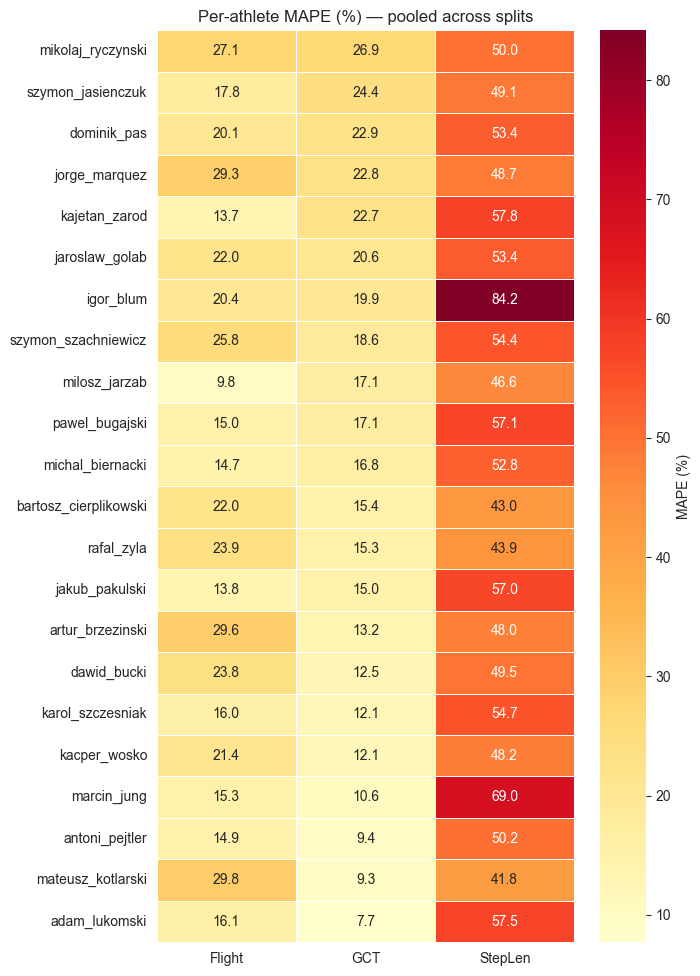

In [16]:
import seaborn as sns

_metric_defs = [
    ("mean_gct_s",         "mean_gct_s_oj",      "GCT"),
    ("mean_flight_s",      "mean_flight_s_oj",   "Flight"),
    ("mean_step_length_m", "mean_step_len_m_oj", "StepLen"),
]

rows = []
for (athlete, split), g in merged.groupby(["athlete", "split"]):
    for vcol, ocol, label in _metric_defs:
        diff  = g[vcol] - g[ocol]
        mae   = diff.abs().mean()
        bias  = diff.mean()
        mape  = (diff.abs() / g[ocol].abs()).mean() * 100
        rows.append({"athlete": athlete, "split": split, "metric": label,
                     "n": len(g), "bias": bias, "MAE": mae, "MAPE (%)": mape})

ath_err = pd.DataFrame(rows)

# ── MAPE heatmap (pooled splits) ─────────────────────────────────────────────
hm = ath_err.pivot_table(index="athlete", columns="metric",
                          values="MAPE (%)", aggfunc="mean")
hm = hm.sort_values("GCT", ascending=False)

fig, ax = plt.subplots(figsize=(7, max(5, len(hm) * 0.38 + 1.5)))
sns.heatmap(hm, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax,
            linewidths=0.4, cbar_kws={"label": "MAPE (%)"})
ax.set_title("Per-athlete MAPE (%) — pooled across splits")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [17]:
TOP_N = 5
for metric_label in ["GCT", "Flight", "StepLen"]:
    print(f"\n── {metric_label}: {TOP_N} highest-error athletes ──")
    sub = ath_err[ath_err["metric"] == metric_label]
    for split in ['train']:
        worst = (sub[sub["split"] == split]
                 .nlargest(TOP_N, "MAPE (%)")
                 [["athlete", "n", "bias", "MAE", "MAPE (%)"]])
        if worst.empty:
            continue
        print(f"  {split}:")
        print(worst.round(4).to_string(index=False, col_space=18))


── GCT: 5 highest-error athletes ──
  train:
           athlete                  n               bias                MAE           MAPE (%)
 mikolaj_ryczynski                  6            -0.0510             0.0510            26.9326
 szymon_jasienczuk                  1            -0.0356             0.0356            24.3721
       dominik_pas                  6            -0.0333             0.0333            22.9137
     jorge_marquez                  5            -0.0369             0.0369            22.7678
     kajetan_zarod                  6            -0.0366             0.0366            22.6955

── Flight: 5 highest-error athletes ──
  train:
            athlete                  n               bias                MAE           MAPE (%)
  mateusz_kotlarski                  6            -0.0741             0.0741            29.8204
   artur_brzezinski                  6            -0.0837             0.0837            29.6456
      jorge_marquez                  5         

## Per-test-id error analysis

Heatmap shows MAPE (%) per test_id and metric (train / test / all splits).
Bar chart compares Video vs. Optojump mean per test_id (pooled across athletes and studies).
Errors are sorted by MAPE for each metric.

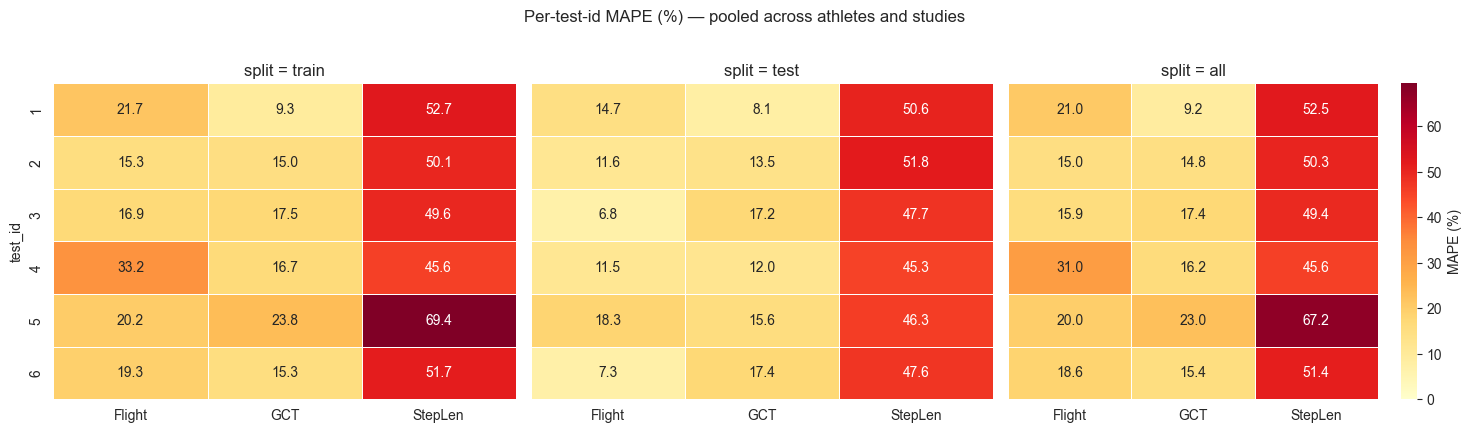

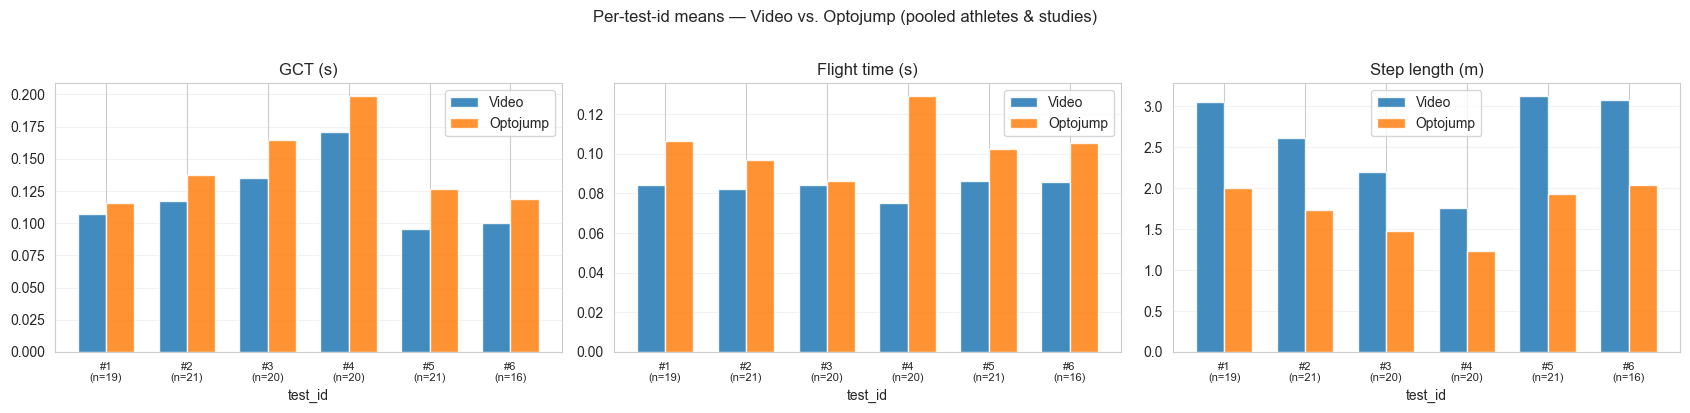

In [18]:
tid_rows = []
for (test_id, split), g in merged.groupby(["test_id", "split"]):
    for vcol, ocol, label in _metric_defs:
        diff = g[vcol] - g[ocol]
        tid_rows.append({
            "test_id":   test_id,
            "split":     split,
            "metric":    label,
            "n":         len(g),
            "bias":      diff.mean(),
            "MAE":       diff.abs().mean(),
            "MAPE (%)":  (diff.abs() / g[ocol].abs()).mean() * 100,
        })

# Also add pooled-split rows (all)
for test_id, g in merged.groupby("test_id"):
    for vcol, ocol, label in _metric_defs:
        diff = g[vcol] - g[ocol]
        tid_rows.append({
            "test_id":  test_id,
            "split":    "all",
            "metric":   label,
            "n":        len(g),
            "bias":     diff.mean(),
            "MAE":      diff.abs().mean(),
            "MAPE (%)": (diff.abs() / g[ocol].abs()).mean() * 100,
        })

tid_err = pd.DataFrame(tid_rows)

# ── MAPE heatmap — one panel per split ───────────────────────────────────────
show_splits = [s for s in ["train", "test", "all"] if s in tid_err["split"].values]
fig, axes = plt.subplots(1, len(show_splits),
                          figsize=(5 * len(show_splits), max(4, merged["test_id"].nunique() * 0.45 + 1.5)),
                          sharey=True)
if len(show_splits) == 1:
    axes = [axes]

vmax = tid_err["MAPE (%)"].max()
for ax, split in zip(axes, show_splits):
    hm = (tid_err[tid_err["split"] == split]
          .pivot_table(index="test_id", columns="metric", values="MAPE (%)", aggfunc="mean")
          .sort_index())
    sns.heatmap(hm, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax,
                linewidths=0.4, vmin=0, vmax=vmax,
                cbar=(split == show_splits[-1]),
                cbar_kws={"label": "MAPE (%)"})
    ax.set_title(f"split = {split}")
    ax.set_xlabel("")
    ax.set_ylabel("test_id" if split == show_splits[0] else "")

plt.suptitle("Per-test-id MAPE (%) — pooled across athletes and studies", y=1.02)
plt.tight_layout()
plt.show()

# ── Bar chart: Video vs Optojump mean per test_id ────────────────────────────
test_ids = sorted(merged["test_id"].unique())
x = np.arange(len(test_ids))
w = 0.35

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, (vcol, ocol, title, color) in zip(axes, METRICS):
    vid_means = [merged[merged["test_id"] == t][vcol].mean() for t in test_ids]
    oj_means  = [merged[merged["test_id"] == t][ocol].mean() for t in test_ids]
    ns        = [int((merged["test_id"] == t).sum()) for t in test_ids]
    ax.bar(x - w / 2, vid_means, w, label="Video",    color='C0',      alpha=0.85)
    ax.bar(x + w / 2, oj_means,  w, label="Optojump", color="C1",  alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([f"#{t}\n(n={n})" for t, n in zip(test_ids, ns)], fontsize=8)
    ax.set_xlabel("test_id")
    ax.set_title(title)
    ax.legend()
    ax.grid(axis="y", alpha=0.25)

plt.suptitle("Per-test-id means — Video vs. Optojump (pooled athletes & studies)", y=1.02)
plt.tight_layout()
plt.show()

In [19]:
print("Per-test-id errors sorted by MAPE — split = all:\n")
for metric_label in ["GCT", "Flight", "StepLen"]:
    sub = (tid_err[(tid_err["metric"] == metric_label) & (tid_err["split"] == "all")]
           .sort_values("MAPE (%)", ascending=False)
           [["test_id", "n", "bias", "MAE", "MAPE (%)"]])
    print(f"  {metric_label}:")
    print(sub.round(4).to_string(index=False, col_space=12))
    print()

Per-test-id errors sorted by MAPE — split = all:

  GCT:
     test_id            n         bias          MAE     MAPE (%)
           5           21      -0.0309       0.0317      22.9885
           3           20      -0.0291       0.0297      17.4479
           4           20      -0.0280       0.0345      16.1879
           6           16      -0.0184       0.0184      15.4054
           2           21      -0.0208       0.0208      14.8189
           1           19      -0.0088       0.0106       9.1548

  Flight:
     test_id            n         bias          MAE     MAPE (%)
           4           20      -0.0541       0.0669      30.9952
           1           19      -0.0224       0.0224      20.9511
           5           21      -0.0162       0.0214      19.9959
           6           16      -0.0197       0.0197      18.5794
           3           20      -0.0020       0.0128      15.9092
           2           21      -0.0148       0.0150      14.9758

  StepLen:
     test_

## Error summary — bias vs. random, train / test breakdown

`systematic_ratio = |bias| / MAE`:  1.0 = all errors have the same sign (purely systematic offset); 0.0 = errors cancel out (purely random).
Rule of thumb used here: ratio > 0.7 → **systematic**, ratio < 0.3 → **random**, otherwise → **mixed**.

In [21]:
summary_rows = []

for split_label, mask in [
    ("train", merged["split"] == "train"),
    ("test",  merged["split"] == "test"),
    ("all",   pd.Series(True, index=merged.index)),
]:
    sub = merged[mask]
    if sub.empty:
        continue
    for vcol, ocol, label, unit in [
        ("mean_gct_s",         "mean_gct_s_oj",      "GCT",         "s"),
        ("mean_flight_s",      "mean_flight_s_oj",   "Flight time", "s"),
        ("mean_step_length_m", "mean_step_len_m_oj", "Step length", "m"),
    ]:
        diff  = sub[vcol] - sub[ocol]
        bias  = diff.mean()
        mae   = diff.abs().mean()
        sd    = diff.std()
        mape  = (diff.abs() / sub[ocol].abs()).mean() * 100
        bias_pct   = bias / sub[ocol].mean() * 100
        loa        = 1.96 * sd
        r          = sub[vcol].corr(sub[ocol])
        sys_ratio  = abs(bias) / mae if mae > 0 else 0.0
        error_type = ("systematic" if sys_ratio > 0.7
                      else "random"     if sys_ratio < 0.3
                      else "mixed")

        summary_rows.append({
            "Split":          split_label,
            "Metric":         f"{label} ({unit})",
            "n":              len(sub),
            "Video mean":     round(sub[vcol].mean(), 4),
            "OJ mean":        round(sub[ocol].mean(), 4),
            "Bias":           f"{bias:+.4f}",
            "Bias %":         f"{bias_pct:+.1f}%",
            "MAE":            round(mae, 4),
            "MAPE":           f"{mape:.1f}%",
            "SD":             round(sd, 4),
            "LoA (±1.96 SD)": round(loa, 4),
            "r":              round(r, 3),
            "sys_ratio":      round(sys_ratio, 2),
            "Error type":     error_type,
        })

summary_df = pd.DataFrame(summary_rows).set_index(["Split", "Metric"])

display(summary_df)

n  Video mean  OJ mean     Bias  Bias %     MAE  \
Split Metric                                                               
train GCT (s)          106      0.1220   0.1454  -0.0234  -16.1%  0.0252   
      Flight time (s)  106      0.0827   0.1053  -0.0226  -21.4%  0.0280   
      Step length (m)  106      2.6206   1.7205  +0.9001  +52.3%  0.9077   
test  GCT (s)           11      0.1172   0.1362  -0.0189  -13.9%  0.0189   
      Flight time (s)   11      0.0840   0.0950  -0.0111  -11.7%  0.0120   
      Step length (m)   11      2.6257   1.7685  +0.8572  +48.5%  0.8572   
all   GCT (s)          117      0.1215   0.1445  -0.0230  -15.9%  0.0246   
      Flight time (s)  117      0.0829   0.1043  -0.0215  -20.6%  0.0265   
      Step length (m)  117      2.6211   1.7250  +0.8960  +51.9%  0.9030   

                        MAPE      SD  LoA (±1.96 SD)      r  sys_ratio  \
Split Metric                                                             
train GCT (s)          16.4%  0.0247          0.0485  0.795       0.93   
      Flight time (s)  21.1%  0.0595          0.1165  0.057       0.81   
      Step length (m)  53.4%  0.3206          0.6284  0.869       0.99   
test  GCT (s)          13.6%  0.0098          0.0191  0.876       1.00   
      Flight time (s)  12.1%  0.0080          0.0158  0.777       0.92   
      Step length (m)  48.3%  0.1524          0.2987  0.992       1.00   
all   GCT (s)          16.1%  0.0237          0.0465  0.797       0.93   
      Flight time (s)  20.2%  0.0567          0.1112  0.063       0.81   
      Step length (m)  52.9%  0.3086          0.6048  0.874       0.99   

                       Error type  
Split Metric                       
train GCT (s)          systematic  
      Flight time (s)  systematic  
      Step length (m)  systematic  
test  GCT (s)          systematic  
      Flight time (s)  systematic  
      Step length (m)  systematic  
all   GCT (s)          systematic  
      Flight time (s)  systematic  
      Step length (m)  systematic

### MAE in frames — quantization floor

At 120 fps each frame = 1/120 ≈ 8.33 ms.  A GCT/flight interval has two independently-quantized boundaries, so the irreducible minimum MAE (with perfect detection) is **1/(3 × fps) × fps = 1/3 ≈ 0.33 frames**.  
`MAE / Floor` shows how many times larger the observed error is compared to that floor.

In [23]:
fps = cfg.fps
quant_floor_frames = 1 / 3  # 1/(3*fps) * fps, independent of fps

frames_rows = []
for (split, metric), row in summary_df.iterrows():
    unit = metric.split("(")[-1].rstrip(")")
    if unit != "s":
        continue  # step length is spatial — frames unit doesn't apply
    mae_frames = float(row["MAE"]) * fps
    frames_rows.append({
        "Split":         split,
        "Metric":        metric,
        "MAE (s)":       row["MAE"],
        "MAE (frames)":  round(mae_frames, 2),
        "Floor (frames)": round(quant_floor_frames, 2),
        "MAE / Floor":   round(mae_frames / quant_floor_frames, 1),
    })

frames_df = pd.DataFrame(frames_rows).set_index(["Split", "Metric"])
display(frames_df)

MAE (s)  MAE (frames)  Floor (frames)  MAE / Floor
Split Metric                                                             
train GCT (s)           0.0252          3.02            0.33          9.1
      Flight time (s)   0.0280          3.36            0.33         10.1
test  GCT (s)           0.0189          2.27            0.33          6.8
      Flight time (s)   0.0120          1.44            0.33          4.3
all   GCT (s)           0.0246          2.95            0.33          8.9
      Flight time (s)   0.0265          3.18            0.33          9.5

---
## Upper bound: ground-truth labels vs. Optojump

Repeats the same error analysis using **manual annotation labels** instead of TCN predictions.
This shows the lowest achievable error given the video frame rate — any remaining gap between
`MAE / Floor` and 1.0 is due to the 120 fps discretisation alone, not model mistakes.

In [25]:
gt_bio_df, gt_steps = make_bio_df(load_labels_annotations)

gt_merged = gt_bio_df.merge(oj_agg, on=["athlete", "study_id", "test_id"], how="inner")
gt_merged["split"] = gt_merged["video_path"].map(
    lambda vp: _manifest_idx[vp]["split"] if vp in _manifest_idx else "unknown"
)
print(
    f"Ground-truth matched: {len(gt_merged)} total  —  "
    f"train: {(gt_merged['split']=='train').sum()},  "
    f"test: {(gt_merged['split']=='test').sum()}"
)

# ── Summary table ─────────────────────────────────────────────────────────────
gt_summary_rows = []
for split_label, mask in [
    ("train", gt_merged["split"] == "train"),
    ("test",  gt_merged["split"] == "test"),
    ("all",   pd.Series(True, index=gt_merged.index)),
]:
    sub = gt_merged[mask]
    if sub.empty:
        continue
    for vcol, ocol, label, unit in [
        ("mean_gct_s",         "mean_gct_s_oj",      "GCT",         "s"),
        ("mean_flight_s",      "mean_flight_s_oj",   "Flight time", "s"),
        ("mean_step_length_m", "mean_step_len_m_oj", "Step length", "m"),
    ]:
        diff       = sub[vcol] - sub[ocol]
        bias       = diff.mean()
        mae        = diff.abs().mean()
        sd         = diff.std()
        mape       = (diff.abs() / sub[ocol].abs()).mean() * 100
        bias_pct   = bias / sub[ocol].mean() * 100
        loa        = 1.96 * sd
        r          = sub[vcol].corr(sub[ocol])
        sys_ratio  = abs(bias) / mae if mae > 0 else 0.0
        error_type = ("systematic" if sys_ratio > 0.7 else
                      "random"     if sys_ratio < 0.3 else "mixed")
        gt_summary_rows.append({
            "Split":          split_label,
            "Metric":         f"{label} ({unit})",
            "n":              len(sub),
            "Video mean":     round(sub[vcol].mean(), 4),
            "OJ mean":        round(sub[ocol].mean(), 4),
            "Bias":           f"{bias:+.4f}",
            "Bias %":         f"{bias_pct:+.1f}%",
            "MAE":            round(mae, 4),
            "MAPE":           f"{mape:.1f}%",
            "SD":             round(sd, 4),
            "LoA (±1.96 SD)": round(loa, 4),
            "r":              round(r, 3),
            "sys_ratio":      round(sys_ratio, 2),
            "Error type":     error_type,
        })

gt_summary_df = pd.DataFrame(gt_summary_rows).set_index(["Split", "Metric"])
display(gt_summary_df)

# ── MAE in frames ─────────────────────────────────────────────────────────────
gt_frames_rows = []
for (split, metric), row in gt_summary_df.iterrows():
    unit = metric.split("(")[-1].rstrip(")")
    if unit != "s":
        continue
    mae_frames = float(row["MAE"]) * fps
    gt_frames_rows.append({
        "Split":          split,
        "Metric":         metric,
        "MAE (s)":        row["MAE"],
        "MAE (frames)":   round(mae_frames, 2),
        "Floor (frames)": round(quant_floor_frames, 2),
        "MAE / Floor":    round(mae_frames / quant_floor_frames, 1),
    })

gt_frames_df = pd.DataFrame(gt_frames_rows).set_index(["Split", "Metric"])
display(gt_frames_df)

Ground-truth matched: 117 total  —  train: 106,  test: 11


n  Video mean  OJ mean     Bias  Bias %     MAE  \
Split Metric                                                               
train GCT (s)          106      0.1266   0.1454  -0.0187  -12.9%  0.0242   
      Flight time (s)  106      0.0903   0.1053  -0.0150  -14.3%  0.0311   
      Step length (m)  106      2.5979   1.7205  +0.8773  +51.0%  0.8848   
test  GCT (s)           11      0.1190   0.1362  -0.0172  -12.6%  0.0172   
      Flight time (s)   11      0.0825   0.0950  -0.0126  -13.2%  0.0136   
      Step length (m)   11      2.6251   1.7685  +0.8566  +48.4%  0.8566   
all   GCT (s)          117      0.1259   0.1445  -0.0186  -12.9%  0.0235   
      Flight time (s)  117      0.0895   0.1043  -0.0148  -14.2%  0.0295   
      Step length (m)  117      2.6004   1.7250  +0.8754  +50.7%  0.8822   

                        MAPE      SD  LoA (±1.96 SD)      r  sys_ratio  \
Split Metric                                                             
train GCT (s)          16.7%  0.0266          0.0521  0.838       0.78   
      Flight time (s)  25.4%  0.0595          0.1167  0.239       0.48   
      Step length (m)  52.2%  0.2998          0.5877  0.875       0.99   
test  GCT (s)          12.6%  0.0098          0.0193  0.875       1.00   
      Flight time (s)  14.2%  0.0096          0.0189  0.671       0.93   
      Step length (m)  48.3%  0.1469          0.2878  0.994       1.00   
all   GCT (s)          16.3%  0.0255          0.0499  0.839       0.79   
      Flight time (s)  24.3%  0.0567          0.1112  0.245       0.50   
      Step length (m)  51.8%  0.2886          0.5656  0.881       0.99   

                       Error type  
Split Metric                       
train GCT (s)          systematic  
      Flight time (s)       mixed  
      Step length (m)  systematic  
test  GCT (s)          systematic  
      Flight time (s)  systematic  
      Step length (m)  systematic  
all   GCT (s)          systematic  
      Flight time (s)       mixed  
      Step length (m)  systematic

MAE (s)  MAE (frames)  Floor (frames)  MAE / Floor
Split Metric                                                             
train GCT (s)           0.0242          2.90            0.33          8.7
      Flight time (s)   0.0311          3.73            0.33         11.2
test  GCT (s)           0.0172          2.06            0.33          6.2
      Flight time (s)   0.0136          1.63            0.33          4.9
all   GCT (s)           0.0235          2.82            0.33          8.5
      Flight time (s)   0.0295          3.54            0.33         10.6

---
## Joint angles — per-video mean trajectories

Plots the mean knee, ankle, and torso angles across all frames for each video.

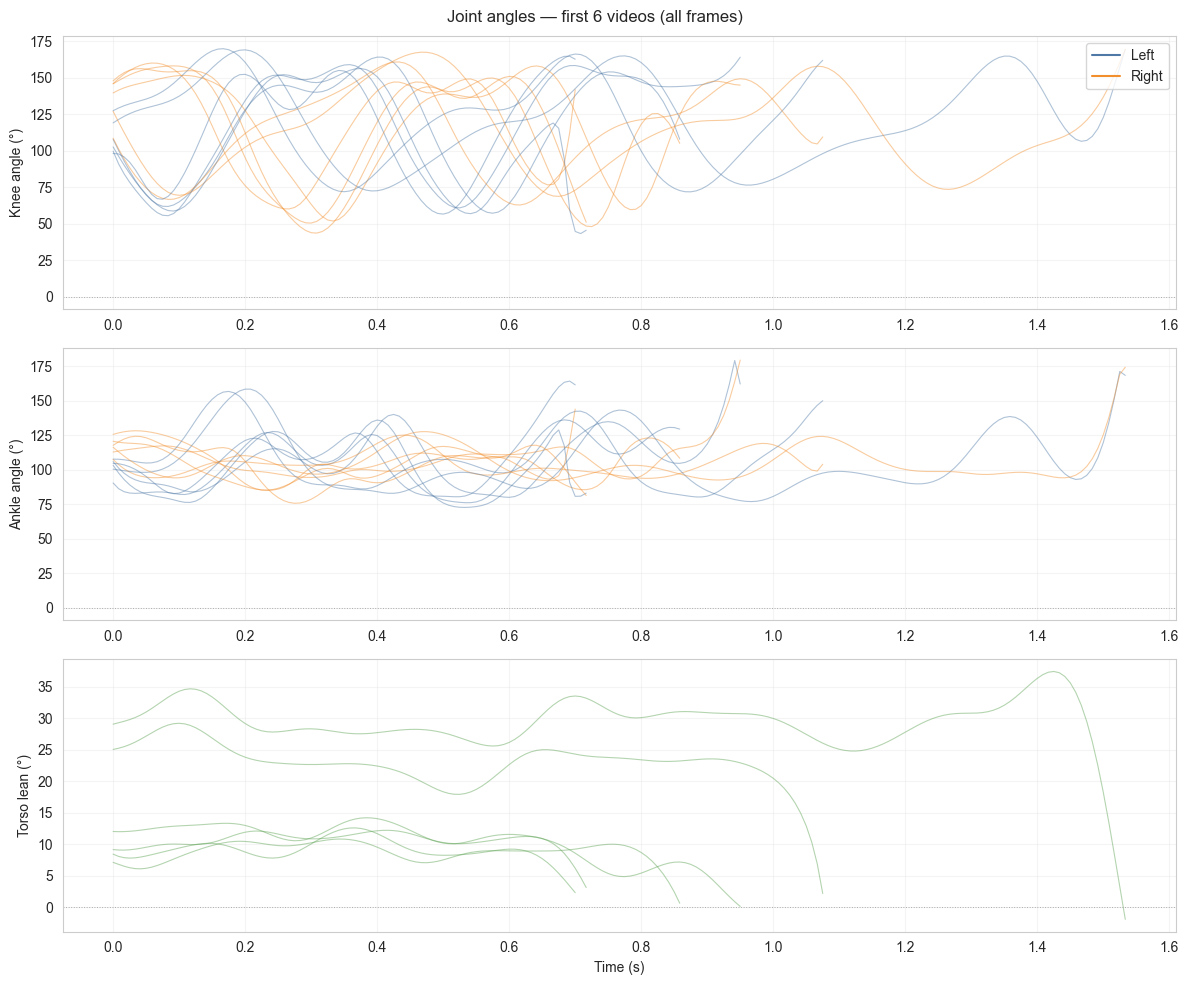

In [24]:
# Compute joint angles for a sample of records (first 6 for brevity)
SAMPLE_N = 6  # TODO: mark detected landings/takeoffs on the plots label them with the angle values; find a table with some generalized values for these metrics;

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)
angle_cols = [
    (["left_knee_angle", "right_knee_angle"], "Knee angle (°)", axes[0]),
    (["left_ankle_angle", "right_ankle_angle"], "Ankle angle (°)", axes[1]),
    (["torso_lean"], "Torso lean (°)", axes[2]),
]
side_colors = {"left": "#4e79a7", "right": "#f28e2b", "torso": "#59a14f"}

for rec, pose_df in pairs[:SAMPLE_N]:
    angles = compute_joint_angles(pose_df)
    t = np.arange(len(angles)) / cfg.fps  # seconds

    for cols, ylabel, ax in angle_cols:
        for col in cols:
            side = col.split("_")[0] if "_" in col else "torso"
            ax.plot(
                t,
                angles[col],
                alpha=0.45,
                linewidth=0.8,
                color=side_colors.get(side, "#aaa"),
                label=f"{rec.athlete} {col}" if rec == pairs[0][0] else None,
            )

for cols, ylabel, ax in angle_cols:
    ax.set_ylabel(ylabel)
    ax.axhline(0, color="#aaa", linewidth=0.7, linestyle=":")
    ax.grid(alpha=0.2)

axes[2].set_xlabel("Time (s)")
# Manual legend for sides
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color=side_colors["left"], label="Left"),
    Line2D([0], [0], color=side_colors["right"], label="Right"),
]
axes[0].legend(handles=legend_elements, loc="upper right")
plt.suptitle(f"Joint angles — first {SAMPLE_N} videos (all frames)")
plt.tight_layout()
plt.show()

---
## Per-step distributions

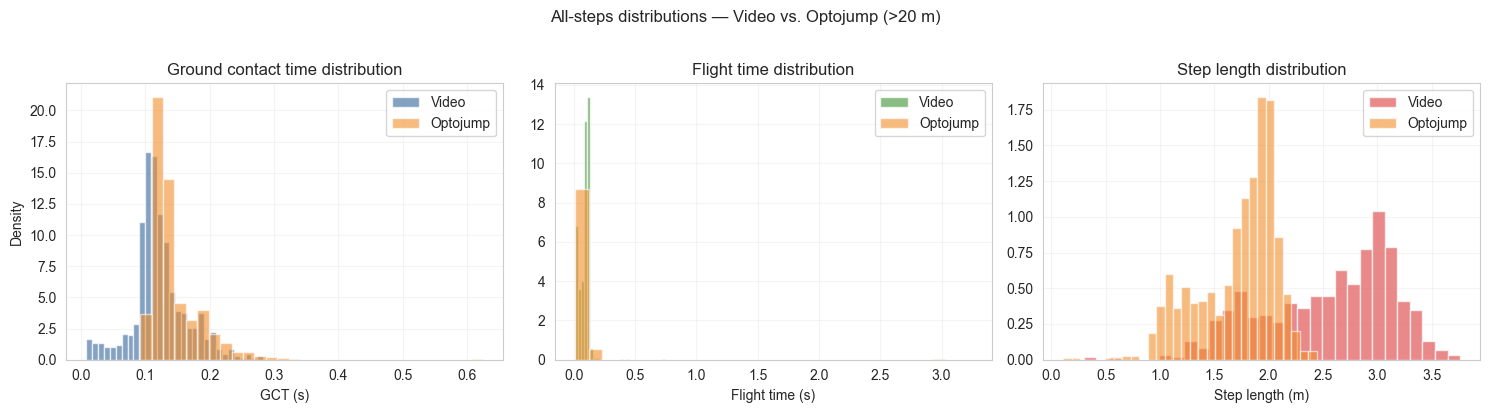

All-step means:
  GCT        — Video: 0.1232 s   Optojump: 0.1442 s
  Flight     — Video: 0.0829 s   Optojump: 0.1058 s
  Step len   — Video: 2.5518 m   Optojump: 1.7200 m


In [23]:
contact_df = pd.DataFrame(contact_all)
flight_df = pd.DataFrame(flight_all)
step_len_df = pd.DataFrame(step_len_all)

oj_steps_post20 = oj_post20.copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# GCT
ax = axes[0]
if len(contact_df):
    ax.hist(
        contact_df["contact_s"],
        bins=30,
        alpha=0.7,
        color="#4e79a7",
        label="Video",
        density=True,
    )
ax.hist(
    oj_steps_post20["contact_time"].dropna(),
    bins=30,
    alpha=0.6,
    color="#f28e2b",
    label="Optojump",
    density=True,
)
ax.set_xlabel("GCT (s)")
ax.set_ylabel("Density")
ax.set_title("Ground contact time distribution")
ax.legend()
ax.grid(alpha=0.2)

# Flight time
ax = axes[1]
if len(flight_df):
    ax.hist(
        flight_df["flight_s"],
        bins=30,
        alpha=0.7,
        color="#59a14f",
        label="Video",
        density=True,
    )
ax.hist(
    oj_steps_post20["flight_time"].dropna(),
    bins=30,
    alpha=0.6,
    color="#f28e2b",
    label="Optojump",
    density=True,
)
ax.set_xlabel("Flight time (s)")
ax.set_title("Flight time distribution")
ax.legend()
ax.grid(alpha=0.2)

# Step length
ax = axes[2]
if len(step_len_df):
    ax.hist(
        step_len_df["step_length_m"].dropna(),
        bins=30,
        alpha=0.7,
        color="#e15759",
        label="Video",
        density=True,
    )
ax.hist(
    oj_steps_post20["step_length_m_oj"].dropna(),
    bins=30,
    alpha=0.6,
    color="#f28e2b",
    label="Optojump",
    density=True,
)
ax.set_xlabel("Step length (m)")
ax.set_title("Step length distribution")
ax.legend()
ax.grid(alpha=0.2)

plt.suptitle("All-steps distributions — Video vs. Optojump (>20 m)", y=1.02)
plt.tight_layout()
plt.show()

# Print means
print("All-step means:")
if len(contact_df):
    print(
        f"  GCT        — Video: {contact_df['contact_s'].mean():.4f} s   "
        f"Optojump: {oj_steps_post20['contact_time'].mean():.4f} s"
    )
if len(flight_df):
    print(
        f"  Flight     — Video: {flight_df['flight_s'].mean():.4f} s   "
        f"Optojump: {oj_steps_post20['flight_time'].mean():.4f} s"
    )
if len(step_len_df):
    print(
        f"  Step len   — Video: {step_len_df['step_length_m'].mean():.4f} m   "
        f"Optojump: {oj_steps_post20['step_length_m_oj'].mean():.4f} m"
    )